In [1]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.0 MB/s  0:00:00 6.0 MB/s eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.compose import TransformedTargetRegressor

from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)

In [3]:
from pathlib import Path
import pandas as pd

candidate_paths = [
    Path("residential_single_family_geocoding_week6.csv"),
    Path("residential_single_family_enriched_week6.csv"),
]

required_cols = [
    "CloseDate",
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "DistrictName",
    "HasUnifiedDistrict",
    "BedBathRatio",
    "TotalRoomsProxy",
    "log_LivingArea",
    "log_LotSize"
]

data_path = None

for path in candidate_paths:
    if path.exists():
        temp = pd.read_csv(path, nrows=5)
        missing = [col for col in required_cols if col not in temp.columns]
        
        print(f"Checking {path}:")
        print("Missing columns:", missing)
        
        if len(missing) == 0:
            data_path = path
            break

if data_path is None:
    raise FileNotFoundError(
        "Could not find a Week 6 dataset with all required engineered/geocoding columns."
    )

model_df = pd.read_csv(data_path, low_memory=False)

print("\nUsing dataset:", data_path)
print("Shape:", model_df.shape)
model_df.head()

Checking residential_single_family_geocoding_week6.csv:
Missing columns: []

Using dataset: residential_single_family_geocoding_week6.csv
Shape: (412013, 96)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,Bathrooms,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,Bedrooms,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSize,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,source_file,BuyerAgentAOR,ListAgentAOR,CloseMonth,LivingArea_missing,Bedrooms_missing,Bathrooms_missing,LotSize_missing,BedBathRatio,TotalRoomsProxy,log_LivingArea,log_LotSize,PropertyAge,row_id,DistrictName,HasUnifiedDistrict
0,"Carpet,Tile",True,NaN,NaN,False,550000.0,542140363,desertap@icloud.com,2022-01-01,560000.0,Shaun,Howe,34.108199,-116.444428,55917 Mountain View Trail,Residential,1546.0,525000.0,34.0,Desert Area Property,Coldwell Banker Roadrunner,NaN,Shaun Howe,NaN,NaN,JT51359,Shantel,Schaut,NaN,NaN,NaN,542140363.0,DC530 - Yucca Valley Southeast,NaN,San Bernardino,Closed,NaN,False,11.0,NaN,SingleFamilyResidence,NaN,Not Applicable-1,JoshuaTreeGateway,1956.0,Item1,55917.0,219067546DA,2.0,Yucca Valley,2.5,NaN,NaN,3.0,2022-01-01,NaN,NaN,2021-11-19,2021-09-14,NaN,NaN,CA,NaN,NaN,True,NaN,NaN,NaN,NaN,27225.00,NaN,NaN,0.0,NaN,92284,NaN,27225.0,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN,2022-01,0,0,0,0,1.5,5.0,7.344073,10.211928,66.0,0,Morongo Unified,1
1,"Laminate,Tile",True,NaN,NaN,True,525000.0,543187090,desertap@icloud.com,2022-01-01,535000.0,Shaun,Howe,34.110490,-116.426066,56753 Lisa Circle,Residential,2061.0,535000.0,14.0,Desert Area Property,Century 21 LOTUS,NaN,Shaun Howe,NaN,NaN,DWONAJES,Jesse,Onate,NaN,NaN,NaN,543187090.0,DC530 - Yucca Valley Southeast,NaN,San Bernardino,Closed,NaN,True,3.0,NaN,SingleFamilyResidence,NaN,Not Applicable-1,Downey,2007.0,Item1,56753.0,219067829DA,2.0,Yucca Valley,2.5,NaN,NaN,4.0,2022-01-01,NaN,NaN,2021-11-12,2021-09-21,NaN,NaN,CA,NaN,NaN,True,1.0,NaN,One,NaN,12232.00,NaN,NaN,3.0,Morongo Unified,92284,NaN,12232.0,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN,2022-01,0,0,0,0,2.0,6.0,7.631432,9.411892,15.0,1,Morongo Unified,1
2,NaN,True,NaN,NaN,False,3895000.0,497949539,Stephen@LissProperties.net,2022-01-02,3300000.0,Stephen,Liss,34.108006,-118.345014,7200 La Presa Drive,Residential,3085.0,3895000.0,16.0,Liss Properties,The Agency,NaN,Stephen Liss,NaN,NaN,CLW-X83729,Jon,Grauman,NaN,NaN,NaN,497949539.0,C03 - Sunset Strip - Hollywood Hills West,NaN,Los Angeles,Closed,NaN,False,2.0,NaN,SingleFamilyResidence,0.9696,NaN,OutofAreaBoard,1953.0,Item1,7200.0,SR20256981,3.0,Los Angeles,2.5,NaN,NaN,3.0,2022-01-02,NaN,NaN,2021-02-13,2021-01-14,NaN,NaN,CA,NaN,NaN,True,1.0,NaN,One,NaN,42237.00,3.0,False,2.0,Los Angeles Unified,90068,0.0,42237.0,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN,2022-01,0,0,0,0,1.0,6.0,8.034631,10.651076,69.0,2,Los Angeles Unified,1
3,NaN,True,NaN,NaN,False,635000.0,547973460,JustinCaudillo@hotmail.com,2022-01-03,615000.0,Justin,Caudillo,33.511093,-116.805415,48960 Shetland Lane,Residential,2607.0,635000.0,53.0,HOMESMART,Jeffrey Charles Golden,NaN,Justin Caudillo,NaN,NaN,SAND-611349,Jerry,Golden,NaN,Monthly,NaN,547973460.0,SRCAR - S

In [4]:
week6_results_path = Path("week6_old_vs_new_feature_comparison.csv")

if not week6_results_path.exists():
    raise FileNotFoundError("Missing week6_old_vs_new_feature_comparison.csv")

week6_results = pd.read_csv(week6_results_path)

week6_results

,Feature Set,Model,R2,MAPE,MdAPE,MAPE_%,MdAPE_%
0,Old Features,Linear Regression,0.292492,0.782359,0.451772,78.235859,45.177248
1,Old Features,Decision Tree,0.264594,0.756144,0.370608,75.614412,37.060808
2,Old Features,Random Forest,0.138849,0.688787,0.334541,68.878718,33.454053
3,New Features + School District,Linear Regression,0.505912,0.529903,0.293466,52.990336,29.346557
4,New Features + School District,Decision Tree,0.343564,0.663734,0.320941,66.373355,32.094089
5,New Features + School District,Random Forest,0.356843,2.371295,0.249375,237.129456,24.937464


In [5]:
week6_new_results = week6_results[
    week6_results["Feature Set"] == "New Features + School District"
].copy()

week6_new_results["Model"] = "Week 6 " + week6_new_results["Model"]

week6_new_results = week6_new_results[
    ["Model", "Feature Set", "R2", "MAPE", "MdAPE"]
]

week6_new_results

,Model,Feature Set,R2,MAPE,MdAPE
3,Week 6 Linear Regression,New Features + School District,0.505912,0.529903,0.293466
4,Week 6 Decision Tree,New Features + School District,0.343564,0.663734,0.320941
5,Week 6 Random Forest,New Features + School District,0.356843,2.371295,0.249375


In [6]:
model_df["CloseDate"] = pd.to_datetime(model_df["CloseDate"], errors="coerce")
model_df["CloseMonth"] = model_df["CloseDate"].dt.to_period("M")

numeric_cols = [
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "Latitude",
    "Longitude",
    "YearBuilt"
]

for col in numeric_cols:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Missing-value flags
base_numeric_features = [
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize"
]

for col in base_numeric_features:
    model_df[f"{col}_missing"] = model_df[col].isna().astype(int)

# Feature engineering
model_df["BedBathRatio"] = model_df["Bedrooms"] / model_df["Bathrooms"].replace(0, np.nan)
model_df["TotalRoomsProxy"] = model_df["Bedrooms"] + model_df["Bathrooms"]
model_df["log_LivingArea"] = np.log1p(model_df["LivingArea"])
model_df["log_LotSize"] = np.log1p(model_df["LotSize"])

if "YearBuilt" in model_df.columns:
    model_df["PropertyAge"] = model_df["CloseDate"].dt.year - model_df["YearBuilt"]
    model_df.loc[
        (model_df["PropertyAge"] < 0) | (model_df["PropertyAge"] > 300),
        "PropertyAge"
    ] = np.nan

# District columns
if "DistrictName" not in model_df.columns:
    raise ValueError("DistrictName is missing. Use the Week 6 dataset after the school district spatial join.")

model_df["DistrictName"] = model_df["DistrictName"].fillna("Unknown")
model_df["HasUnifiedDistrict"] = (model_df["DistrictName"] != "Unknown").astype(int)

model_df = model_df.dropna(subset=["CloseDate", "ClosePrice"]).copy()
model_df = model_df.sort_values("CloseDate").reset_index(drop=True)

print("Date range:", model_df["CloseDate"].min(), "to", model_df["CloseDate"].max())
print("Rows:", len(model_df))

Date range: 2022-01-01 00:00:00 to 2026-06-30 00:00:00
Rows: 412013


In [7]:
all_months = sorted(model_df["CloseMonth"].dropna().unique())

test_month = all_months[-1]
train_months = [m for m in all_months if m < test_month]

train_df = model_df[model_df["CloseMonth"] < test_month].copy()
test_df = model_df[model_df["CloseMonth"] == test_month].copy()

print("Test month:", test_month)
print("Train date range:", train_df["CloseDate"].min(), "to", train_df["CloseDate"].max())
print("Test date range:", test_df["CloseDate"].min(), "to", test_df["CloseDate"].max())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Test month: 2026-06
Train date range: 2022-01-01 00:00:00 to 2026-05-31 00:00:00
Test date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00
Train rows: 399155
Test rows: 12858


In [8]:
validation_month = sorted(train_df["CloseMonth"].dropna().unique())[-1]

tune_train_df = train_df[train_df["CloseMonth"] < validation_month].copy()
val_df = train_df[train_df["CloseMonth"] == validation_month].copy()

print("Validation month:", validation_month)
print("Tuning train rows:", len(tune_train_df))
print("Validation rows:", len(val_df))

Validation month: 2026-05
Tuning train rows: 387131
Validation rows: 12024


In [9]:
min_district_count = 100

district_counts = train_df["DistrictName"].fillna("Unknown").value_counts()
common_districts = set(district_counts[district_counts >= min_district_count].index)

model_df["DistrictName_Grouped"] = model_df["DistrictName"].fillna("Unknown")
model_df.loc[
    ~model_df["DistrictName_Grouped"].isin(common_districts),
    "DistrictName_Grouped"
] = "OtherDistrict"

# Recreate splits after adding grouped district feature
train_df = model_df[model_df["CloseMonth"] < test_month].copy()
test_df = model_df[model_df["CloseMonth"] == test_month].copy()

tune_train_df = train_df[train_df["CloseMonth"] < validation_month].copy()
val_df = train_df[train_df["CloseMonth"] == validation_month].copy()

print("Number of common districts kept:", len(common_districts))
print(train_df["DistrictName_Grouped"].value_counts().head(15))

Number of common districts kept: 206
DistrictName_Grouped
Unknown                        100578
Los Angeles Unified             38469
San Diego Unified               10572
Capistrano Unified               7090
Desert Sands Unified             7030
Palm Springs Unified             5998
Oakland Unified                  5179
Corona-Norco Unified             5011
Hemet Unified                    4872
Long Beach Unified               4702
Riverside Unified                4576
Temecula Valley Unified          4421
Mt. Diablo Unified               4156
San Bernardino City Unified      3722
Lake Elsinore Unified            3486
Name: count, dtype: int64


In [10]:
target = "ClosePrice"

advanced_numeric_features = [
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "LivingArea_missing",
    "Bedrooms_missing",
    "Bathrooms_missing",
    "LotSize_missing",
    "BedBathRatio",
    "TotalRoomsProxy",
    "log_LivingArea",
    "log_LotSize",
    "HasUnifiedDistrict"
]

if "PropertyAge" in model_df.columns:
    advanced_numeric_features.append("PropertyAge")

advanced_categorical_features = [
    "DistrictName_Grouped"
]

all_features = advanced_numeric_features + advanced_categorical_features

missing_features = [col for col in all_features + [target] if col not in model_df.columns]

print("Missing features:", missing_features)
print("Numeric features:", advanced_numeric_features)
print("Categorical features:", advanced_categorical_features)

Missing features: []
Numeric features: ['LivingArea', 'Bedrooms', 'Bathrooms', 'LotSize', 'LivingArea_missing', 'Bedrooms_missing', 'Bathrooms_missing', 'LotSize_missing', 'BedBathRatio', 'TotalRoomsProxy', 'log_LivingArea', 'log_LotSize', 'HasUnifiedDistrict', 'PropertyAge']
Categorical features: ['DistrictName_Grouped']


In [11]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    mask = y_true != 0
    y_true_nonzero = y_true[mask]
    y_pred_nonzero = y_pred[mask]
    
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true_nonzero, y_pred_nonzero)
    mdape = np.median(
        np.abs((y_true_nonzero - y_pred_nonzero) / y_true_nonzero)
    )
    
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    return {
        "R2": r2,
        "MAPE": mape,
        "MdAPE": mdape,
        "MAE": mae,
        "RMSE": rmse
    }

In [12]:
def build_xgb_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    transformers = [
        ("num", numeric_transformer, numeric_features)
    ]
    
    if len(categorical_features) > 0:
        transformers.append(("cat", categorical_transformer, categorical_features))
    
    return ColumnTransformer(
        transformers=transformers,
        sparse_threshold=1.0
    )

In [13]:
X_tune_train = tune_train_df[all_features]
y_tune_train = tune_train_df[target]

X_val = val_df[all_features]
y_val = val_df[target]

X_train = train_df[all_features]
y_train = train_df[target]

X_test = test_df[all_features]
y_test = test_df[target]

print("Tune train:", X_tune_train.shape)
print("Validation:", X_val.shape)
print("Final train:", X_train.shape)
print("Test:", X_test.shape)

Tune train: (387131, 15)
Validation: (12024, 15)
Final train: (399155, 15)
Test: (12858, 15)


In [14]:
max_tuning_rows = 150_000

if len(tune_train_df) > max_tuning_rows:
    tune_train_sample = tune_train_df.sample(
        n=max_tuning_rows,
        random_state=42
    )
else:
    tune_train_sample = tune_train_df.copy()

X_tune_sample = tune_train_sample[all_features]
y_tune_sample = tune_train_sample[target]

print("Tuning sample rows:", len(tune_train_sample))

Tuning sample rows: 150000


In [15]:
def make_xgb_pipeline(params, log_target=False):
    preprocessor = build_xgb_preprocessor(
        advanced_numeric_features,
        advanced_categorical_features
    )
    
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        **params
    )
    
    if log_target:
        model_step = TransformedTargetRegressor(
            regressor=xgb_model,
            func=np.log1p,
            inverse_func=np.expm1
        )
    else:
        model_step = xgb_model
    
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model_step)
    ])
    
    return pipe

In [16]:
param_grid = [
    {
        "max_depth": 3,
        "learning_rate": 0.05,
        "n_estimators": 250,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "min_child_weight": 5
    },
    {
        "max_depth": 4,
        "learning_rate": 0.05,
        "n_estimators": 300,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "min_child_weight": 5
    },
    {
        "max_depth": 5,
        "learning_rate": 0.03,
        "n_estimators": 400,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "min_child_weight": 10
    },
    {
        "max_depth": 5,
        "learning_rate": 0.08,
        "n_estimators": 250,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "min_child_weight": 10
    },
    {
        "max_depth": 6,
        "learning_rate": 0.05,
        "n_estimators": 300,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "min_child_weight": 15
    }
]

tuning_rows = []

for i, params in enumerate(param_grid, start=1):
    for log_target in [False, True]:
        print(f"Training candidate {i}, log_target={log_target}")
        
        pipe = make_xgb_pipeline(params, log_target=log_target)
        pipe.fit(X_tune_sample, y_tune_sample)
        
        val_preds = pipe.predict(X_val)
        val_preds = np.maximum(val_preds, 0)
        
        metrics = regression_metrics(y_val, val_preds)
        
        row = {
            "Candidate": i,
            "LogTarget": log_target,
            **params,
            "Validation_R2": metrics["R2"],
            "Validation_MAPE": metrics["MAPE"],
            "Validation_MdAPE": metrics["MdAPE"],
            "Validation_MAE": metrics["MAE"],
            "Validation_RMSE": metrics["RMSE"]
        }
        
        tuning_rows.append(row)

tuning_results = pd.DataFrame(tuning_rows)

tuning_results["Validation_MAPE_%"] = tuning_results["Validation_MAPE"] * 100
tuning_results["Validation_MdAPE_%"] = tuning_results["Validation_MdAPE"] * 100

tuning_results.sort_values("Validation_MdAPE")

Training candidate 1, log_target=False
Training candidate 1, log_target=True
Training candidate 2, log_target=False
Training candidate 2, log_target=True
Training candidate 3, log_target=False
Training candidate 3, log_target=True
Training candidate 4, log_target=False
Training candidate 4, log_target=True
Training candidate 5, log_target=False
Training candidate 5, log_target=True


,Candidate,LogTarget,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,min_child_weight,Validation_R2,Validation_MAPE,Validation_MdAPE,Validation_MAE,Validation_RMSE,Validation_MAPE_%,Validation_MdAPE_%
7,4,True,5,0.08,250,0.85,0.85,10,0.418460,0.304962,0.198518,377445.634549,1.279669e+06,30.496186,19.851849
9,5,True,6,0.05,300,0.85,0.85,15,0.417553,0.307581,0.201408,380227.328109,1.280665e+06,30.758055,20.140840
5,3,True,5,0.03,400,0.90,0.90,10,0.395331,0.326163,0.219704,400965.196301,1.304867e+06,32.616264,21.970359
3,2,True,4,0.05,300,0.90,0.90,5,0.387834,0.331137,0.222693,405940.950896,1.312931e+06,33.113708,22.269350
1,1,True,3,0.05,250,0.90,0.90,5,0.354762,0.353246,0.241032,429957.731816,1.347931e+06,35.324582,24.103224
8,5,False,6,0.05,300,0.85,0.85,15,0.221032,0.459008,0.244657,453508.493939,1.481042e+06,45.900844,24.465726
6,4,False,5,0.08,250,0.85,0.85,10,0.256739,0.455039,0.245603,448167.347891,1.446699e+06,45.503913,24.560326
4,3,False,5,0.03,400,0.90,0.90,10,0.322070,0.462909,0.265186,451126.920405,1.381656e+06,46.290925,26.518576
2,2,False,4,0.05,300,0.90,0.90,5,0.257423,0.466503,0.268983,454750.466037,1.446033e+06,46.650294,26.898306
0,1,False,3,0.05,250,0.90,0.90,5,0.294129,0.496502,0.290454,475021.091962,1.409842e+06,49.650156,29.045440


In [17]:
best_tuning_row = tuning_results.sort_values("Validation_MdAPE").iloc[0]

best_params = {
    "max_depth": int(best_tuning_row["max_depth"]),
    "learning_rate": float(best_tuning_row["learning_rate"]),
    "n_estimators": int(best_tuning_row["n_estimators"]),
    "subsample": float(best_tuning_row["subsample"]),
    "colsample_bytree": float(best_tuning_row["colsample_bytree"]),
    "min_child_weight": float(best_tuning_row["min_child_weight"])
}

best_log_target = bool(best_tuning_row["LogTarget"])

print("Best tuning row:")
print(best_tuning_row)

print("\nBest params:")
print(best_params)
print("Use log target:", best_log_target)

Best tuning row:
Candidate                          4
LogTarget                       True
max_depth                          5
learning_rate                   0.08
n_estimators                     250
subsample                       0.85
colsample_bytree                0.85
min_child_weight                  10
Validation_R2                0.41846
Validation_MAPE             0.304962
Validation_MdAPE            0.198518
Validation_MAE         377445.634549
Validation_RMSE       1279668.529826
Validation_MAPE_%          30.496186
Validation_MdAPE_%         19.851849
Name: 7, dtype: object

Best params:
{'max_depth': 5, 'learning_rate': 0.08, 'n_estimators': 250, 'subsample': 0.85, 'colsample_bytree': 0.85, 'min_child_weight': 10.0}
Use log target: True


In [18]:
final_xgb_model = make_xgb_pipeline(
    best_params,
    log_target=best_log_target
)

final_xgb_model.fit(X_train, y_train)

xgb_test_preds = final_xgb_model.predict(X_test)
xgb_test_preds = np.maximum(xgb_test_preds, 0)

xgb_test_metrics = regression_metrics(y_test, xgb_test_preds)

xgb_test_metrics

{'R2': 0.6153165425219165,
 'MAPE': 0.36911806482880594,
 'MdAPE': np.float64(0.19959747509446923),
 'MAE': np.float64(377141.259572348),
 'RMSE': np.float64(952920.2192891138)}

In [19]:
week6_reference_results = pd.DataFrame([
    {
        "Model": "Week 6 Linear Regression",
        "Feature Set": "New Features + School District",
        "R2": 0.505912,
        "MAPE": 0.529903,
        "MdAPE": 0.293466,
        "MAE": np.nan,
        "RMSE": np.nan
    },
    {
        "Model": "Week 6 Random Forest",
        "Feature Set": "New Features + School District",
        "R2": 0.356843,
        "MAPE": 2.371295,
        "MdAPE": 0.249375,
        "MAE": np.nan,
        "RMSE": np.nan
    }
])

week7_results = pd.DataFrame([
    {
        "Model": "Week 7 XGBoost",
        "Feature Set": "New Features + School District",
        "R2": xgb_test_metrics["R2"],
        "MAPE": xgb_test_metrics["MAPE"],
        "MdAPE": xgb_test_metrics["MdAPE"],
        "MAE": xgb_test_metrics["MAE"],
        "RMSE": xgb_test_metrics["RMSE"]
    }
])

advanced_comparison_results = pd.concat(
    [week6_reference_results, week7_results],
    ignore_index=True
)

advanced_comparison_results["MAPE_%"] = advanced_comparison_results["MAPE"] * 100
advanced_comparison_results["MdAPE_%"] = advanced_comparison_results["MdAPE"] * 100

advanced_comparison_results

,Model,Feature Set,R2,MAPE,MdAPE,MAE,RMSE,MAPE_%,MdAPE_%
0,Week 6 Linear Regression,New Features + School District,0.505912,0.529903,0.293466,NaN,NaN,52.990300,29.346600
1,Week 6 Random Forest,New Features + School District,0.356843,2.371295,0.249375,NaN,NaN,237.129500,24.937500
2,Week 7 XGBoost,New Features + School District,0.615317,0.369118,0.199597,377141.259572,952920.219289,36.911806,19.959748


In [20]:
tuning_results.to_csv("week7_xgboost_tuning_results.csv", index=False)
advanced_comparison_results.to_csv("week7_advanced_model_test_metrics.csv", index=False)

print("Saved tuning results and final test metrics.")

Saved tuning results and final test metrics.


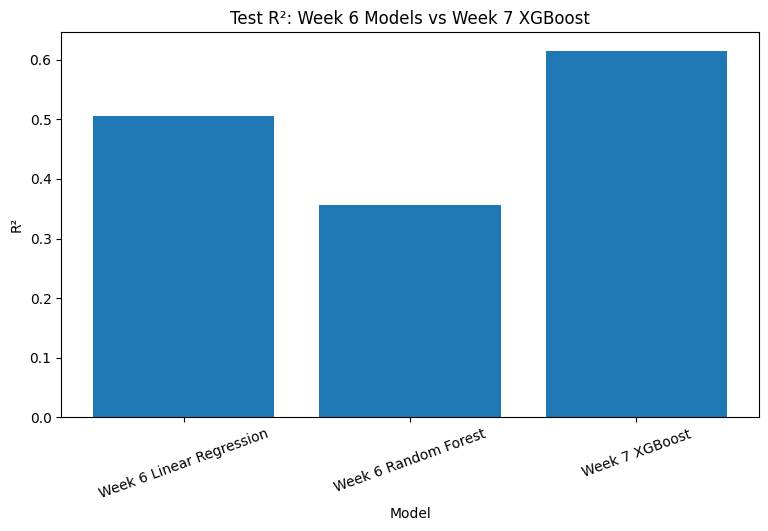

In [21]:
plt.figure(figsize=(9, 5))

plt.bar(
    advanced_comparison_results["Model"],
    advanced_comparison_results["R2"]
)

plt.title("Test R²: Week 6 Models vs Week 7 XGBoost")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.show()

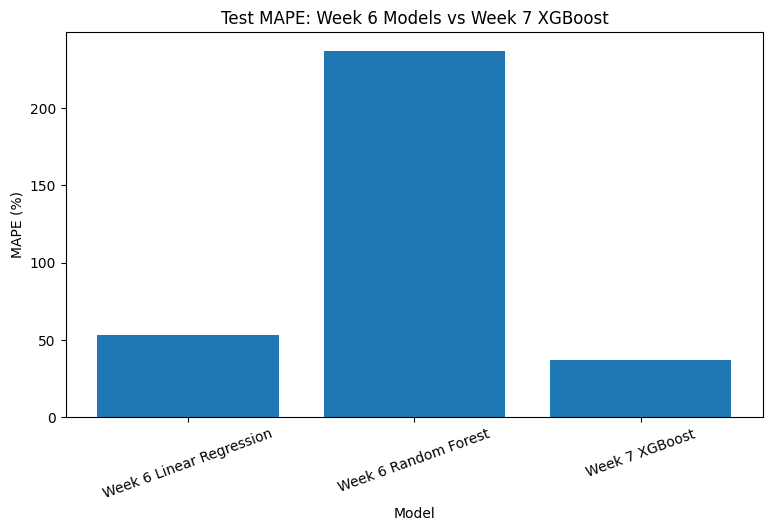

In [22]:
plt.figure(figsize=(9, 5))

plt.bar(
    advanced_comparison_results["Model"],
    advanced_comparison_results["MAPE_%"]
)

plt.title("Test MAPE: Week 6 Models vs Week 7 XGBoost")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=20)
plt.show()

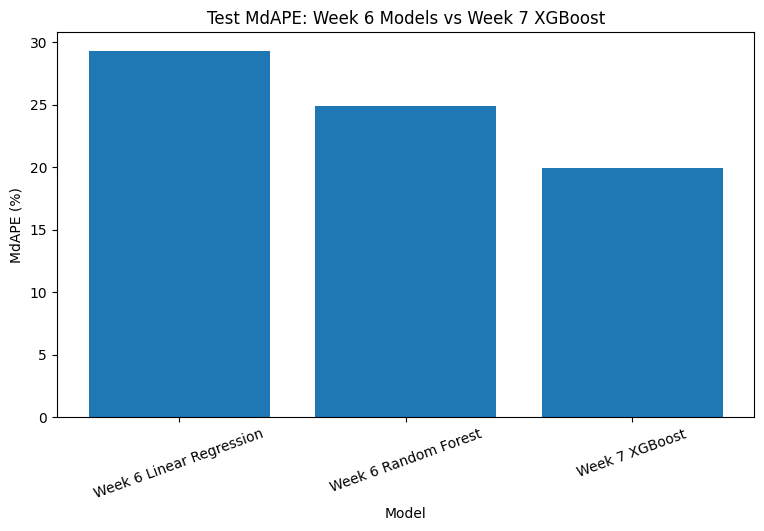

In [23]:
plt.figure(figsize=(9, 5))

plt.bar(
    advanced_comparison_results["Model"],
    advanced_comparison_results["MdAPE_%"]
)

plt.title("Test MdAPE: Week 6 Models vs Week 7 XGBoost")
plt.xlabel("Model")
plt.ylabel("MdAPE (%)")
plt.xticks(rotation=20)
plt.show()

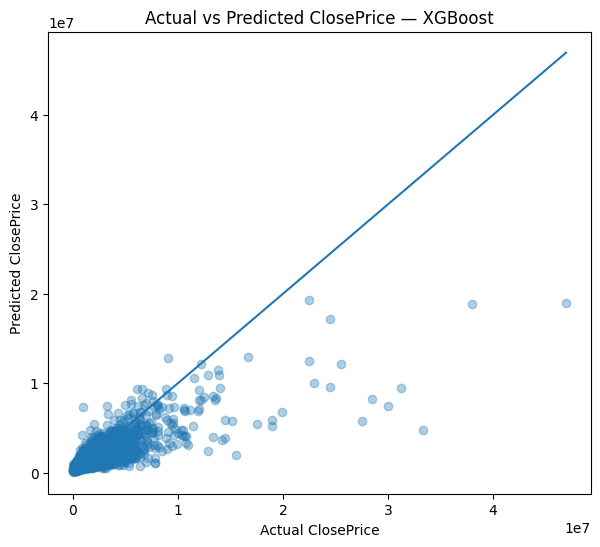

In [24]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, xgb_test_preds, alpha=0.35)

min_price = min(y_test.min(), xgb_test_preds.min())
max_price = max(y_test.max(), xgb_test_preds.max())

plt.plot([min_price, max_price], [min_price, max_price])

plt.title("Actual vs Predicted ClosePrice — XGBoost")
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.show()

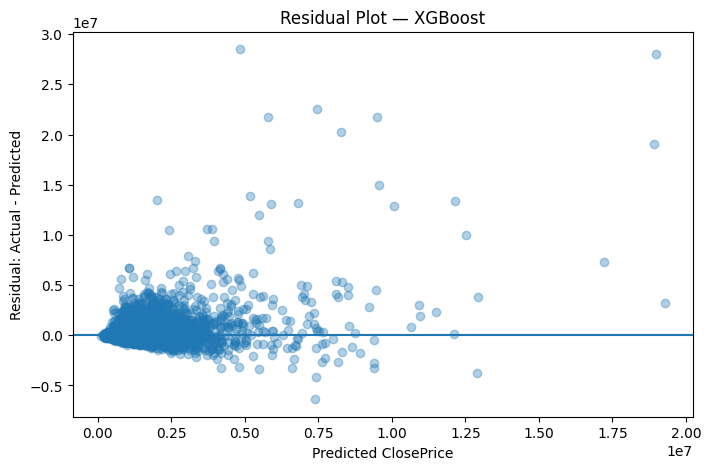

In [25]:
xgb_residuals = y_test - xgb_test_preds

plt.figure(figsize=(8, 5))
plt.scatter(xgb_test_preds, xgb_residuals, alpha=0.35)
plt.axhline(0)

plt.title("Residual Plot — XGBoost")
plt.xlabel("Predicted ClosePrice")
plt.ylabel("Residual: Actual - Predicted")
plt.show()

In [26]:
xgb_error_df = test_df[["CloseDate", "ClosePrice"]].copy()
xgb_error_df["PredictedClosePrice_XGB"] = xgb_test_preds
xgb_error_df["AbsoluteError_XGB"] = (
    xgb_error_df["ClosePrice"] - xgb_error_df["PredictedClosePrice_XGB"]
).abs()
xgb_error_df["APE_XGB"] = (
    xgb_error_df["AbsoluteError_XGB"] / xgb_error_df["ClosePrice"]
)

xgb_error_summary = xgb_error_df["APE_XGB"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

xgb_error_summary

count    12858.000000
mean         0.369118
std          8.955253
min          0.000028
50%          0.199597
75%          0.362453
90%          0.583398
95%          0.771245
99%          1.575261
max       1011.706034
Name: APE_XGB, dtype: float64

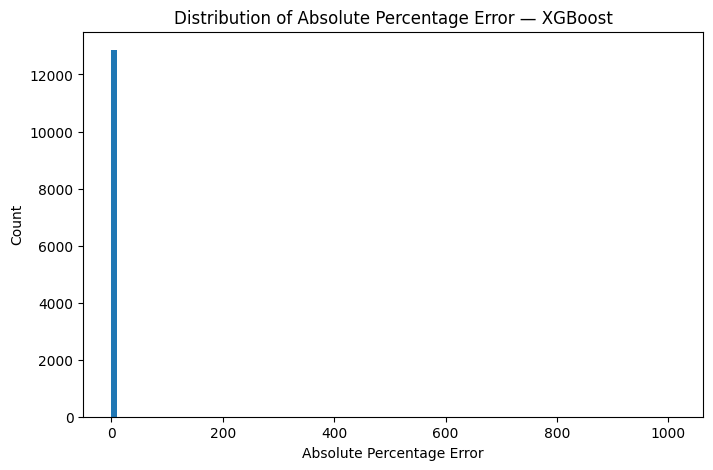

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(xgb_error_df["APE_XGB"].dropna(), bins=100)
plt.title("Distribution of Absolute Percentage Error — XGBoost")
plt.xlabel("Absolute Percentage Error")
plt.ylabel("Count")
plt.show()

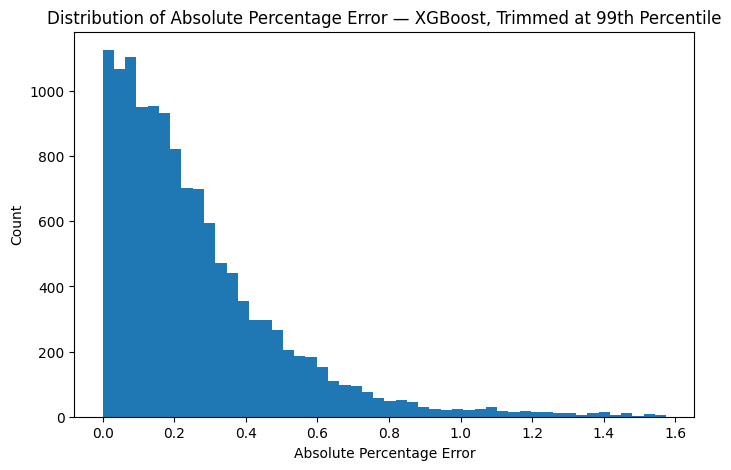

In [28]:
ape_upper = xgb_error_df["APE_XGB"].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    xgb_error_df.loc[xgb_error_df["APE_XGB"] <= ape_upper, "APE_XGB"].dropna(),
    bins=50
)

plt.title("Distribution of Absolute Percentage Error — XGBoost, Trimmed at 99th Percentile")
plt.xlabel("Absolute Percentage Error")
plt.ylabel("Count")
plt.show()

In [29]:
price_bin_df = test_df[["ClosePrice"]].copy()

price_bin_df["PriceBin"] = pd.qcut(
    price_bin_df["ClosePrice"],
    q=5,
    labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Highest"]
)

price_bin_df["XGB_APE"] = (
    np.abs(price_bin_df["ClosePrice"] - xgb_test_preds)
    / price_bin_df["ClosePrice"]
)

xgb_price_bin_results = price_bin_df.groupby("PriceBin", observed=True).agg(
    median_close_price=("ClosePrice", "median"),
    xgb_mdape=("XGB_APE", "median"),
    count=("ClosePrice", "count")
).reset_index()

xgb_price_bin_results["xgb_mdape_%"] = xgb_price_bin_results["xgb_mdape"] * 100

xgb_price_bin_results

,PriceBin,median_close_price,xgb_mdape,count,xgb_mdape_%
0,Lowest,449000.0,0.316266,2617,31.626626
1,Low-Mid,699000.0,0.158327,2546,15.832748
2,Middle,925000.0,0.140057,2561,14.005703
3,High-Mid,1340000.0,0.183707,2563,18.370665
4,Highest,2398000.0,0.282926,2571,28.292626


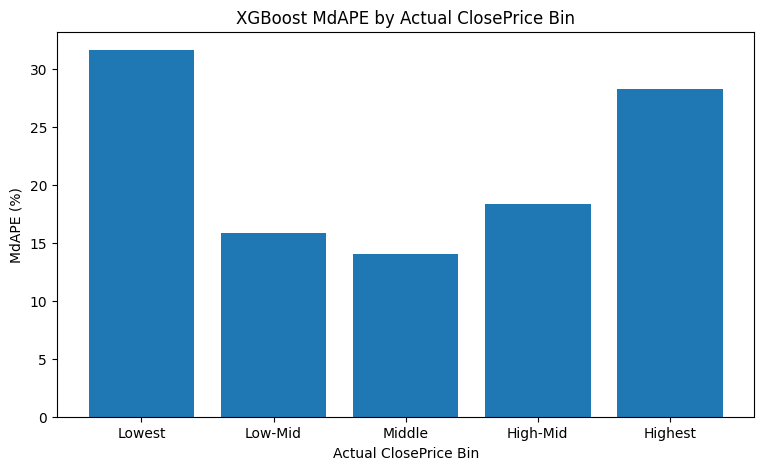

In [30]:
plt.figure(figsize=(9, 5))

plt.bar(
    xgb_price_bin_results["PriceBin"],
    xgb_price_bin_results["xgb_mdape_%"]
)

plt.title("XGBoost MdAPE by Actual ClosePrice Bin")
plt.xlabel("Actual ClosePrice Bin")
plt.ylabel("MdAPE (%)")
plt.show()

In [31]:
preprocessor = final_xgb_model.named_steps["preprocessor"]
model_step = final_xgb_model.named_steps["model"]

if isinstance(model_step, TransformedTargetRegressor):
    xgb_estimator = model_step.regressor_
else:
    xgb_estimator = model_step

feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_estimator.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(25)

,feature,importance
10,num__log_LivingArea,0.022219
2,num__Bathrooms,0.021055
82,cat__DistrictName_Grouped_Hemet Unified,0.020422
122,cat__DistrictName_Grouped_Morongo Unified,0.019306
171,cat__DistrictName_Grouped_San Jose Unified,0.017877
139,cat__DistrictName_Grouped_OtherDistrict,0.017557
160,cat__DistrictName_Grouped_Rim of the World Uni...,0.017310
29,cat__DistrictName_Grouped_Barstow Unified,0.017202
0,num__LivingArea,0.016687
143,cat__DistrictName_Grouped_Palo Alto Unified,0.016556


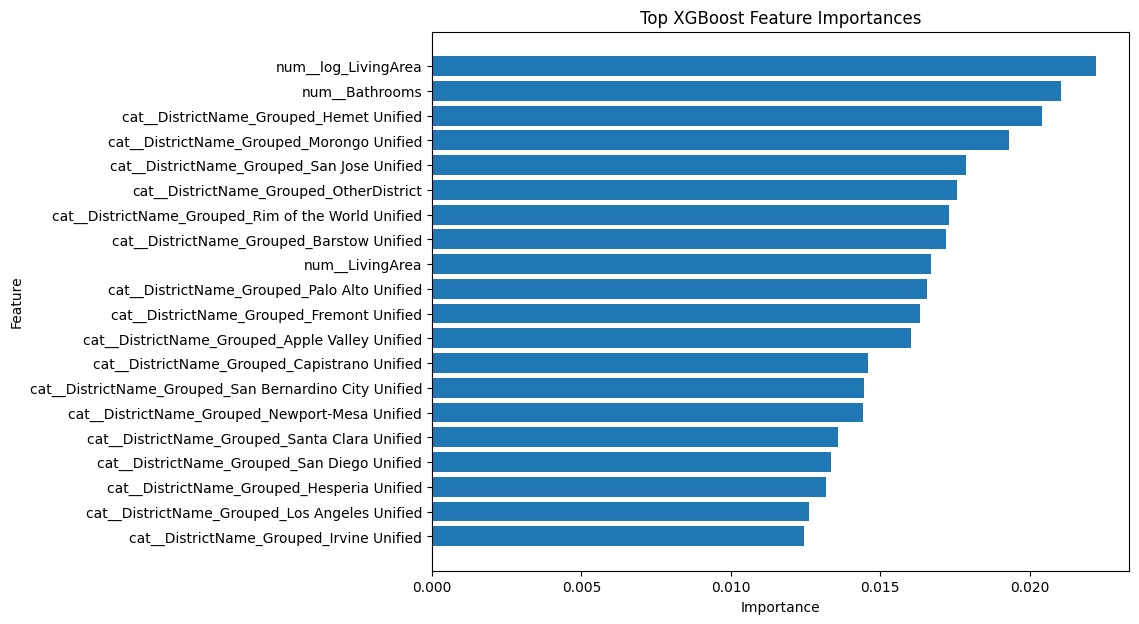

In [32]:
top_n = 20

top_importances = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(top_importances["feature"], top_importances["importance"])

plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [33]:
advanced_display = advanced_comparison_results.copy()

advanced_display["R2"] = advanced_display["R2"].round(4)
advanced_display["MAPE_%"] = advanced_display["MAPE_%"].round(2)
advanced_display["MdAPE_%"] = advanced_display["MdAPE_%"].round(2)
advanced_display["MAE"] = advanced_display["MAE"].round(0)
advanced_display["RMSE"] = advanced_display["RMSE"].round(0)

advanced_display = advanced_display[
    ["Model", "Feature Set", "R2", "MAPE_%", "MdAPE_%", "MAE", "RMSE"]
]

advanced_display.sort_values("R2", ascending=False)

,Model,Feature Set,R2,MAPE_%,MdAPE_%,MAE,RMSE
2,Week 7 XGBoost,New Features + School District,0.6153,36.91,19.96,377141.0,952920.0
0,Week 6 Linear Regression,New Features + School District,0.5059,52.99,29.35,NaN,NaN
1,Week 6 Random Forest,New Features + School District,0.3568,237.13,24.94,NaN,NaN


In [34]:
week6_lr = advanced_comparison_results[
    advanced_comparison_results["Model"] == "Week 6 Linear Regression"
].iloc[0]

week6_rf = advanced_comparison_results[
    advanced_comparison_results["Model"] == "Week 6 Random Forest"
].iloc[0]

week7_xgb = advanced_comparison_results[
    advanced_comparison_results["Model"] == "Week 7 XGBoost"
].iloc[0]

improvement_summary = pd.DataFrame([
    {
        "Comparison": "XGBoost vs Week 6 Linear Regression",
        "R2_Change": week7_xgb["R2"] - week6_lr["R2"],
        "MAPE_pp_Change": (week7_xgb["MAPE"] - week6_lr["MAPE"]) * 100,
        "MdAPE_pp_Change": (week7_xgb["MdAPE"] - week6_lr["MdAPE"]) * 100
    },
    {
        "Comparison": "XGBoost vs Week 6 Random Forest",
        "R2_Change": week7_xgb["R2"] - week6_rf["R2"],
        "MAPE_pp_Change": (week7_xgb["MAPE"] - week6_rf["MAPE"]) * 100,
        "MdAPE_pp_Change": (week7_xgb["MdAPE"] - week6_rf["MdAPE"]) * 100
    }
])

improvement_summary

,Comparison,R2_Change,MAPE_pp_Change,MdAPE_pp_Change
0,XGBoost vs Week 6 Linear Regression,0.109405,-16.078494,-9.386852
1,XGBoost vs Week 6 Random Forest,0.258474,-200.217694,-4.977752


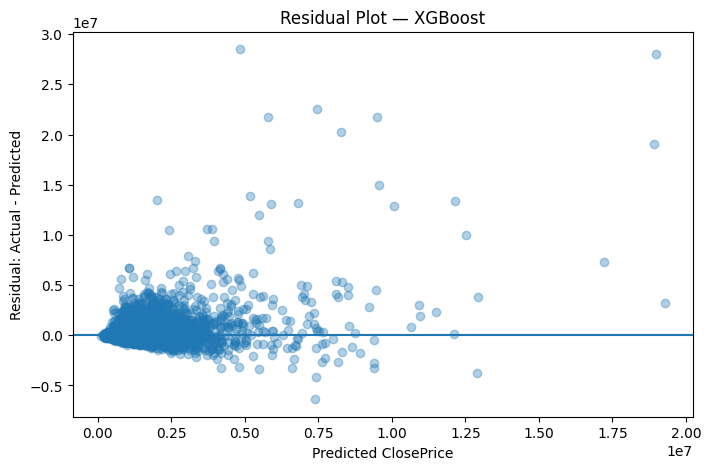

In [35]:
xgb_residuals = y_test - xgb_test_preds

plt.figure(figsize=(8, 5))
plt.scatter(xgb_test_preds, xgb_residuals, alpha=0.35)
plt.axhline(0)

plt.title("Residual Plot — XGBoost")
plt.xlabel("Predicted ClosePrice")
plt.ylabel("Residual: Actual - Predicted")
plt.show()

In [36]:
xgb_error_df = test_df[["CloseDate", "ClosePrice"]].copy()

xgb_error_df["PredictedClosePrice_XGB"] = xgb_test_preds
xgb_error_df["AbsoluteError_XGB"] = (
    xgb_error_df["ClosePrice"] - xgb_error_df["PredictedClosePrice_XGB"]
).abs()

xgb_error_df["APE_XGB"] = (
    xgb_error_df["AbsoluteError_XGB"] / xgb_error_df["ClosePrice"]
)

xgb_error_summary = xgb_error_df["APE_XGB"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

xgb_error_summary

count    12858.000000
mean         0.369118
std          8.955253
min          0.000028
50%          0.199597
75%          0.362453
90%          0.583398
95%          0.771245
99%          1.575261
max       1011.706034
Name: APE_XGB, dtype: float64

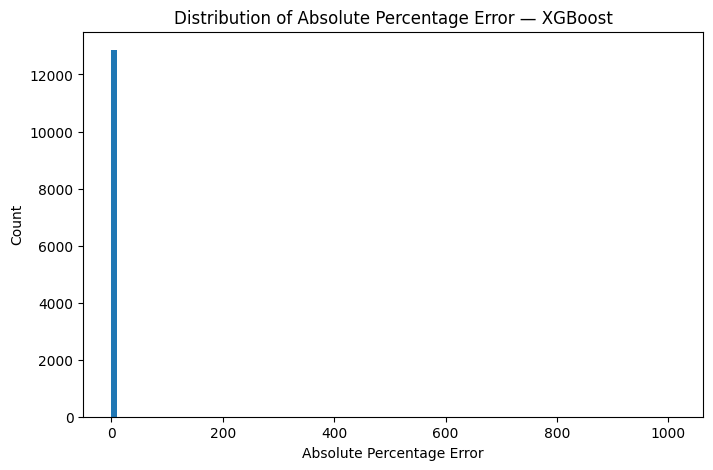

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    xgb_error_df["APE_XGB"].dropna(),
    bins=100
)

plt.title("Distribution of Absolute Percentage Error — XGBoost")
plt.xlabel("Absolute Percentage Error")
plt.ylabel("Count")
plt.show()

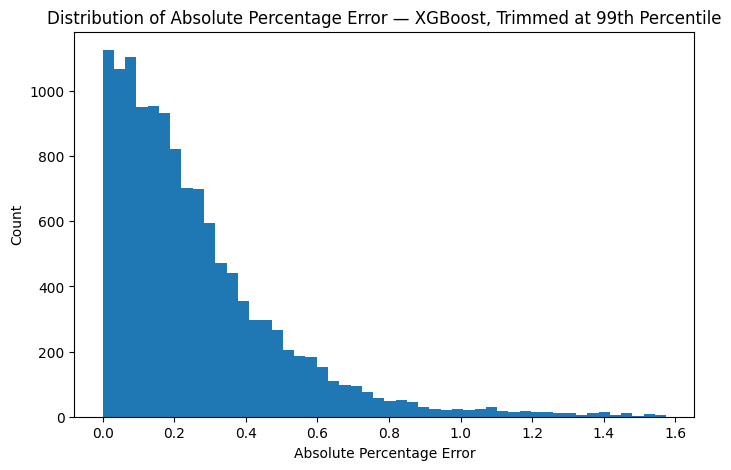

In [38]:
ape_upper = xgb_error_df["APE_XGB"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    xgb_error_df.loc[
        xgb_error_df["APE_XGB"] <= ape_upper,
        "APE_XGB"
    ].dropna(),
    bins=50
)

plt.title("Distribution of Absolute Percentage Error — XGBoost, Trimmed at 99th Percentile")
plt.xlabel("Absolute Percentage Error")
plt.ylabel("Count")
plt.show()

In [39]:
price_bin_df = test_df[["ClosePrice"]].copy()

price_bin_df["PriceBin"] = pd.qcut(
    price_bin_df["ClosePrice"],
    q=5,
    labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Highest"]
)

price_bin_df["XGB_APE"] = (
    np.abs(price_bin_df["ClosePrice"] - xgb_test_preds)
    / price_bin_df["ClosePrice"]
)

xgb_price_bin_results = price_bin_df.groupby("PriceBin", observed=True).agg(
    median_close_price=("ClosePrice", "median"),
    xgb_mdape=("XGB_APE", "median"),
    count=("ClosePrice", "count")
).reset_index()

xgb_price_bin_results["xgb_mdape_%"] = xgb_price_bin_results["xgb_mdape"] * 100

xgb_price_bin_results

,PriceBin,median_close_price,xgb_mdape,count,xgb_mdape_%
0,Lowest,449000.0,0.316266,2617,31.626626
1,Low-Mid,699000.0,0.158327,2546,15.832748
2,Middle,925000.0,0.140057,2561,14.005703
3,High-Mid,1340000.0,0.183707,2563,18.370665
4,Highest,2398000.0,0.282926,2571,28.292626


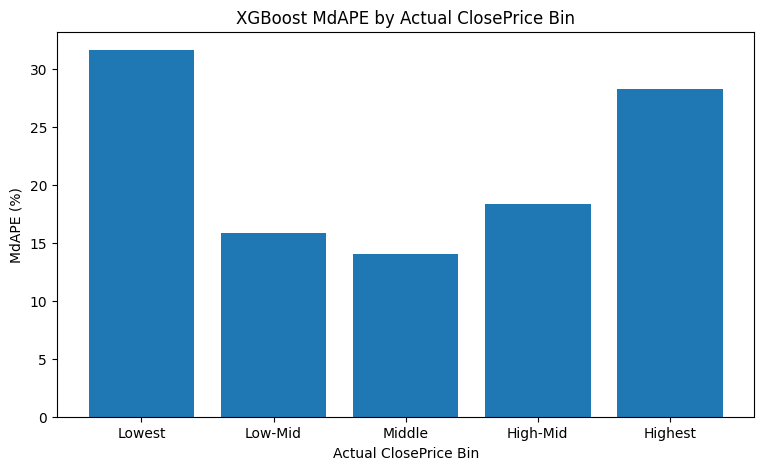

In [40]:
plt.figure(figsize=(9, 5))

plt.bar(
    xgb_price_bin_results["PriceBin"],
    xgb_price_bin_results["xgb_mdape_%"]
)

plt.title("XGBoost MdAPE by Actual ClosePrice Bin")
plt.xlabel("Actual ClosePrice Bin")
plt.ylabel("MdAPE (%)")
plt.show()

## Week 7 Results Summary

For Week 7, I trained an advanced gradient boosting model using XGBoost to see whether it could improve on the Week 6 models. I used the same enriched feature set from Week 6, including engineered property features and the school district layer from the spatial join.

I kept the same chronological evaluation approach. June 2026 was held out as the final test month, and all previous months were used for training. For light hyperparameter tuning, I used May 2026 as a validation month so that the June test set remained untouched during model selection.

The XGBoost tuning process tested different combinations of maximum tree depth, learning rate, number of estimators, subsampling, column subsampling, and minimum child weight. I also tested both raw `ClosePrice` and log-transformed `ClosePrice` targets. The log-transformed target consistently performed better than the raw target on validation MdAPE, which makes sense because housing prices are highly skewed and percentage-based metrics are sensitive to extreme values.

The best validation model used:

- `max_depth`: 5
- `learning_rate`: 0.08
- `n_estimators`: 250
- `subsample`: 0.85
- `colsample_bytree`: 0.85
- `min_child_weight`: 10
- Log target: True

On the June 2026 test set, the final XGBoost model achieved an R² of approximately 0.615, MAPE of approximately 36.91%, and MdAPE of approximately 19.96%.

This is the strongest result so far. Compared with the Week 6 Linear Regression model, XGBoost improved R² from about 0.506 to 0.615, reduced MAPE from about 52.99% to 36.91%, and reduced MdAPE from about 29.35% to 19.96%. Compared with the Week 6 Random Forest model, XGBoost also improved MdAPE while avoiding the extreme MAPE instability seen in the Random Forest.

The main takeaway is that gradient boosting was able to make better use of the engineered and geographic features than the previous models. XGBoost improved both overall variance explanation and typical percentage-error performance, making it the best model so far by R², MAPE, and MdAPE.

This week, I trained an advanced gradient boosting model using XGBoost and tuned a small set of hyperparameters, including tree depth, learning rate, and number of estimators. I used May 2026 as a validation month for tuning and kept June 2026 as the final test month.

The best XGBoost model used a log-transformed target and achieved the strongest results so far: R² of about 0.615, MAPE of about 36.91%, and MdAPE of about 19.96%. This improved over last week’s best balanced model, Linear Regression, which had an R² of about 0.506, MAPE of about 52.99%, and MdAPE of about 29.35%.

The standout finding was that XGBoost improved both overall accuracy and typical prediction error. Last week, Random Forest had the best MdAPE but suffered from extreme MAPE outliers. XGBoost achieved an even better MdAPE while keeping MAPE much more stable, making it the best model so far.

In [41]:
# Saving XGBoost test predictions for later evaluation

week7_predictions = test_df.copy()

week7_predictions["PredictedClosePrice_XGB"] = xgb_test_preds
week7_predictions["AbsoluteError_XGB"] = (
    week7_predictions["ClosePrice"] - week7_predictions["PredictedClosePrice_XGB"]
).abs()

week7_predictions["APE_XGB"] = (
    week7_predictions["AbsoluteError_XGB"] / week7_predictions["ClosePrice"]
)

week7_predictions.to_csv("week7_xgboost_test_predictions.csv", index=False)

print("Saved week7_xgboost_test_predictions.csv")
print(week7_predictions.shape)
week7_predictions[["CloseDate", "ClosePrice", "PredictedClosePrice_XGB", "AbsoluteError_XGB", "APE_XGB"]].head()

Saved week7_xgboost_test_predictions.csv
(12858, 100)


,CloseDate,ClosePrice,PredictedClosePrice_XGB,AbsoluteError_XGB,APE_XGB
399155,2026-06-01,1310000.0,1.064614e+06,245386.5000,0.187318
399156,2026-06-01,540000.0,7.492882e+05,209288.1875,0.387571
399157,2026-06-01,1440000.0,1.657415e+06,217414.8750,0.150983
399158,2026-06-01,890000.0,4.651057e+05,424894.3125,0.477409
399159,2026-06-01,858000.0,9.339427e+05,75942.6875,0.088511
